In [1]:
import os
from pathlib import Path
from skimage import io
import matplotlib.pyplot as plt

from imagegrains import data_loader, segmentation_helper, grainsizing,plotting

import warnings
warnings.filterwarnings("ignore")

>> Initializing ImageGrains with CellposeSAM:


Welcome to CellposeSAM, cellpose v
cellpose version: 	4.0.6 
platform:       	win32 
python version: 	3.10.18 
torch version:  	2.7.1+cu118! The neural network component of
CPSAM is much larger than in previous versions and CPU excution is slow. 
We encourage users to use GPU/MPS if available. 




## Download pre-trained models and demo data  
If you have not donwloaded the pre-trained models and demo data yet from github, please see notebook **1_image_segmentation**. If you want to run on your own data, you can set the path manually in the next cell.

In [2]:
#set path to predicted masks (segmentation model output)
data_path = "F:/cellpose/fh/"

This notebook will try to use segementation results from the previous notebook **1_image_segmentation**.

In [3]:
download_path = Path.home().joinpath('imagegrains')
data_path = download_path.joinpath('demo_data','FH').as_posix()

## Measure grain sizes in labels and predictions

Grain sizes are measured for all image files of masks in `data_path` with a specific format (`mask_format`, default = tif). `data_path` can have sub-folders named 'test', 'train'. If `do_subfolders == True` any existing sub-folder will be used.   
- A string (`mask_str`) for filtering file names can be used.
- Alternatives to the default ellipsoid fitting are available (can be specified  with `fit_method`).

Parameters
----------
`data_path` (str) - path to the dataset.  
`mask_format` (str (optional, default = 'tif')) - format of the mask images.  
`mask_str` (str (optional, default = '')) - string that is contained in the mask images; e.g., '_mask' for lables, '_pred' for predictions  
`tar_dir` (str (optional, default = '')) - path to the target directory  
`filters` (dict (optional, default = None)) - dictionary of filters to apply to the grains  
`mute` (bool (optional, default = False)) - mute the console output.  
`outline_threshold` (float (optional, default =.5)) - Angular tolerance threshold for b-axis detection during outline fitting in degree (°).  
`properties` (list (optional, default = ['label','area', 'area_convex','perimeter_crofton','orientation','minor_axis_length','major_axis_length','solidity','eccentricity','centroid','local_centroid','bbox'])) - list of properties to be extracted from the masks.   
`fit_method` (str (optional, default = '')) - method to fit the grain outlines. Options are,'convex_hull','mask_outline'. If fit_method is not specified, ellipsoidal fit will be used. ! Please note that using 'convex_hull' or 'mask_outline' will be slow.  
`return_results` (bool (optional, default =False)) - return the results as a list of pandas dataframes.  
`save_results` (bool (optional, default = True)) - save the results as csv files.  
`do_subfolders` (bool (optional, default = False)) - if True, the function will also measure 

In [4]:
#optional filters for grain size measuring
filters= {
    'edge':[True,.1],'px_cutoff':[True,12]
    }
#optional properties for regionprops
properties=['label','area','area_convex','perimeter_crofton','orientation','minor_axis_length','major_axis_length','solidity','eccentricity','centroid','local_centroid','bbox']

In [5]:
#measure grain sizes of ground truth
lbl_grains,lbl_res_props,lbl_ids = grainsizing.batch_grainsize(data_path,filters=filters,mask_str='_mask',properties=properties,
                                                               mute=True,return_results=True,do_subfolders=False)

C:\Users\3DUser\imagegrains\demo_data\FH\train: 100%|██████████████████████████████████| 6/6 [00:01<00:00,  4.51file/s]


In [6]:
#ascertain Cellpose version
try:
    from imagegrains import __cp_version__
except:
    __cp_version__ = 2

#set model_id to default model based on Cellpose version
if __cp_version__ < 4:
    model_id = 'IG2_full_set'
elif __cp_version__ >= 4:
    model_id = 'IG2_full_set_cp_SAM'

#measure grain sizes of predictions with filter tags
pred_grains,pred_res_props,pred_ids = grainsizing.batch_grainsize(data_path,filters=filters,mask_str=f'_{model_id}_pred',properties=properties,
                                                                  mute=True,return_results=True,do_subfolders=False)

C:\Users\3DUser\imagegrains\demo_data\FH\train: 100%|██████████████████████████████████| 6/6 [00:01<00:00,  5.12file/s]


### Load predictions, labels and images

In [7]:
#get image-, label- and pred-paths
imgs,lbls,_ = data_loader.dataset_loader(data_path,label_str='mask')
_,_,preds = data_loader.dataset_loader(data_path,pred_str=f'_{model_id}_pred')
#map to train/test split
preds = segmentation_helper.map_preds_to_imgs(preds,imgs,p_string=f'_{model_id}_pred')
#set plot elements
elements= ['image','mask','ellipse_b','ellipse_a','ellipse']

### Re-order the results to match the order of the images

In [8]:
pred_grains,pred_res_props,pred_ids= grainsizing.map_grain_res_to_img(imgs,pred_grains,pred_res_props,pred_ids,p_string=f'_{model_id}_pred')

### Plot grains, approximations and axes

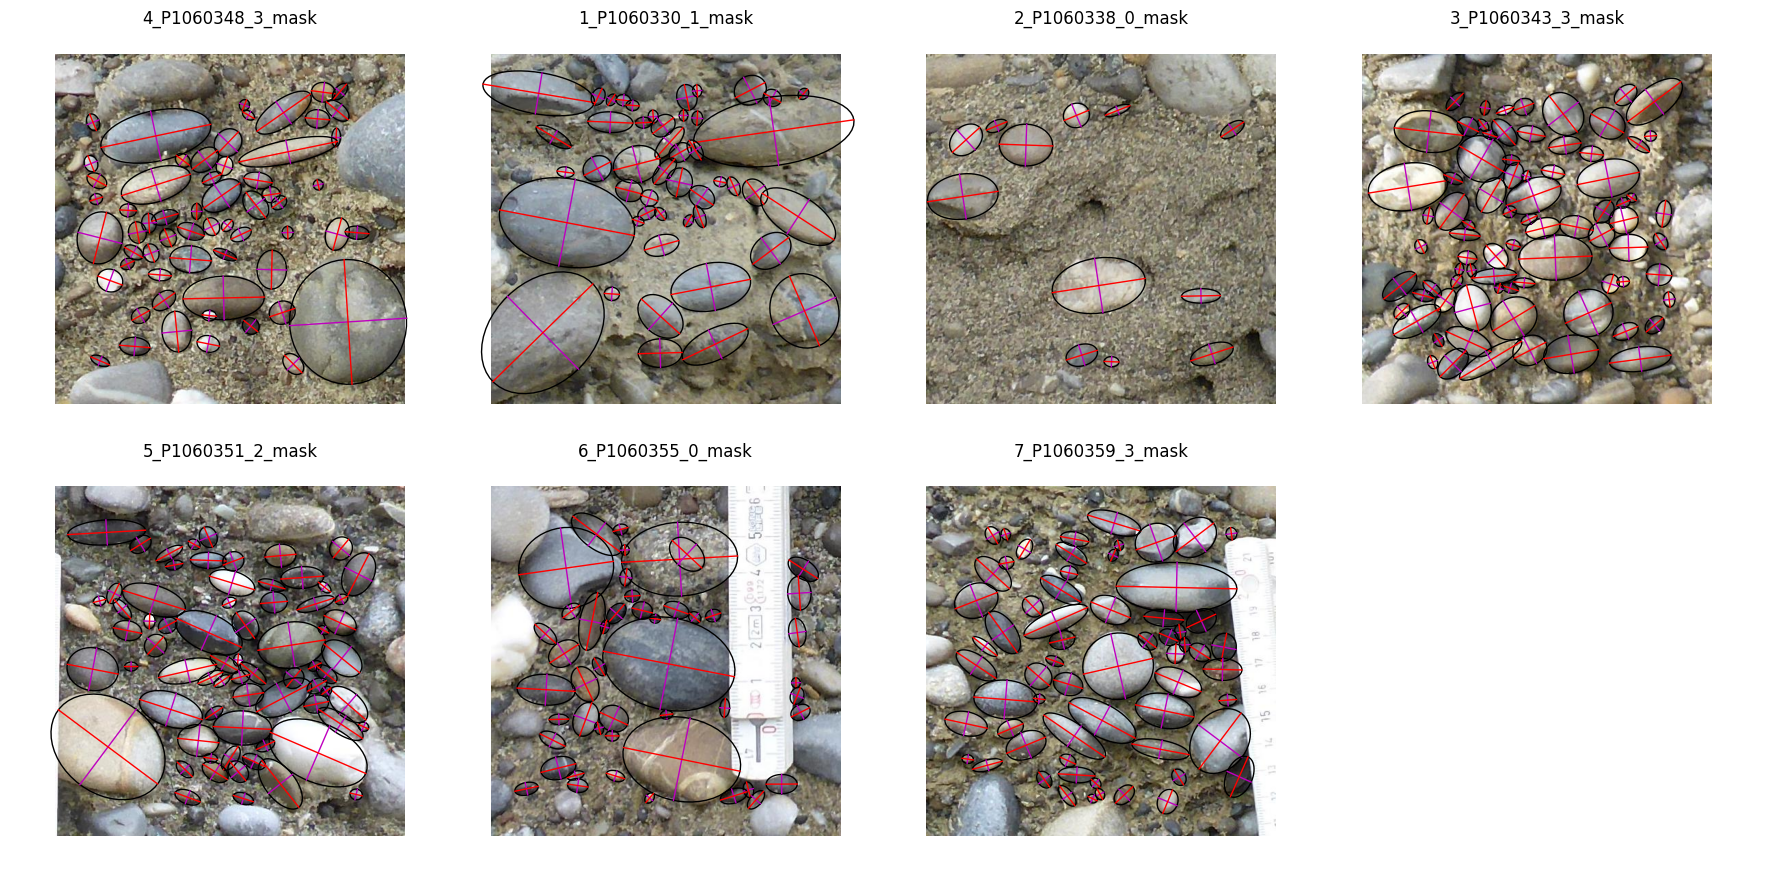

In [9]:
fig,axs = plotting.inspect_dataset_grains(imgs,lbls,res_props=lbl_res_props);
axs.axis('off');

## Re-scale grain sizes with image resolution

In [10]:
#average image resolution
resolution = 0.39
grainsizing.re_scale_dataset(data_path,resolution=resolution,gsd_str='_grains',return_results=True,save_gsds=True);

# camera parameters for estimating the image resolution (optional) - can be passed to `grainsizing.re_scale_dataset()`
camera_parameters = {
    'image_distance_m': [], 
    'focal_length_mm': [],
    'sensorH_mm': [],
    'sensorW_mm': [],
    'pixelsW':[],
    'pixelsH':[],
    }

## Optional: Resample the grains with a regular grid

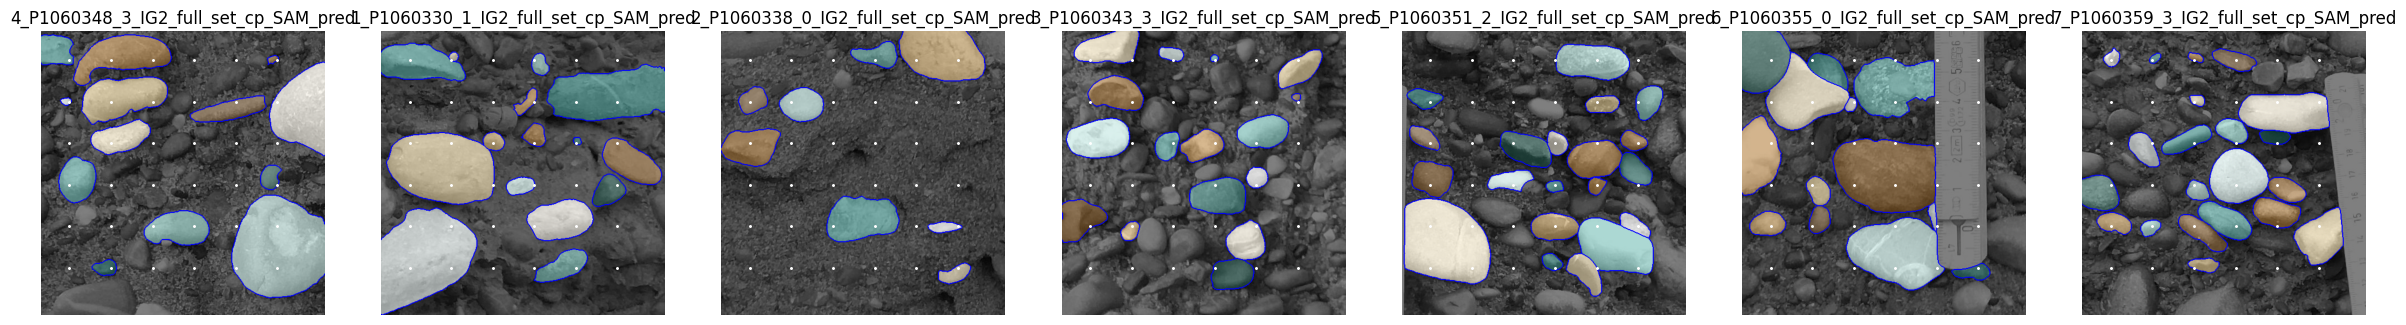

In [11]:
#create output folder
out_dir = Path(f'{data_path}/grid_resampled')
os.makedirs(out_dir,exist_ok=True)

plt.figure(figsize=(30,20))
for i,masks in enumerate(preds):
    plt.subplot(1,len(preds),i+1)
    #get ID from file name
    file_id = Path(masks).stem
    #load masks from file
    mask = io.imread(str(masks))
    #resample mask to grid
    grid_resampled,xx,yy = grainsizing.resample_masks(mask,filters=filters,grid_size=75,mute=True)
    #plot mask and resampled mask
    plotting.plot_single_img_mask(io.imread(str(imgs[i])),grid_resampled,file_id)
    #plot grid
    plt.scatter(yy,xx,marker='.',color='w',s=5)
    #save resampled mask to file 
    io.imsave(f'{out_dir}/{file_id}_resampled.tif',grid_resampled)
    #io.imsave(data_path+'/grid_resampled_preds/'+file_id+'_resampled.tif',grid_resampled)

## Optional: Save individual grains (masks, sliced image, outline) to file

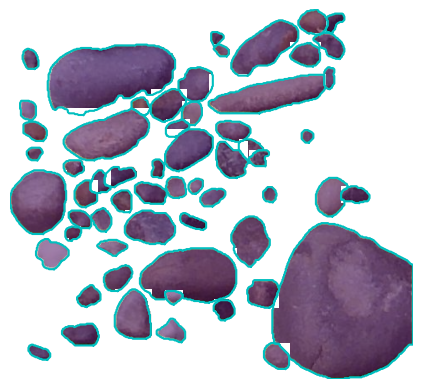

In [12]:
#single image
tar_dir=Path(data_path).joinpath('grain_outlines').as_posix()
os.makedirs(tar_dir,exist_ok=True)
grainsizing.export_grain_outline(io.imread(str(lbls[0])),img=io.imread(str(imgs[0])),tar_dir=str(tar_dir),props=lbl_res_props[0],file_id='demo',plot_summary=True)
#full dataset
grainsizing.batch_outline(lbls,imgs,prop_l=lbl_res_props,tar_dir=str(tar_dir))